# Preprocessing Validation — Bowel Sound Classification

This notebook visually validates each preprocessing step: bandpass filtering, RMS normalisation, and data augmentation. All design decisions are grounded in EDA findings.

In [1]:
import sys, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy.signal import welch
from pathlib import Path

sys.path.insert(0, str(Path("../src").resolve()))
from preprocessing import bandpass_filter, rms_normalise, augment_clip
from config import (
    SR,
    N_MELS,
    N_FFT,
    HOP_LENGTH,
    DATA_DIR,
    SEED,
    TARGET_CLASSES,
    CLASS_TO_IDX,
)
from audio import load_audio_files
from dataset import BowelSoundDataset, get_splits

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

FIG_DIR = Path("figures/preprocessing")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load EDA summary
with open(DATA_DIR / "eda_summary.json") as f:
    eda = json.load(f)
LOW_HZ, HIGH_HZ = eda["dominant_freq_band_hz"]
CLIP_DUR = eda["recommended_segment_duration_s"]

print(f"Bandpass range: {LOW_HZ:.1f} – {HIGH_HZ:.1f} Hz")
print(f"Clip duration: {CLIP_DUR}s")

Bandpass range: 21.5 – 409.1 Hz
Clip duration: 0.5s


In [2]:
# Load audio and pick one representative event per class
audio = load_audio_files()
ds_base = BowelSoundDataset(clip_duration=CLIP_DUR)

# Pick events near median duration for each class
examples = {}
for cls in TARGET_CLASSES:
    cls_events = [(i, e) for i, e in enumerate(ds_base.events) if e["label"] == cls]
    durations = [e["end"] - e["start"] for _, e in cls_events]
    median_dur = np.median(durations)
    best_i, best_e = min(
        cls_events, key=lambda x: abs((x[1]["end"] - x[1]["start"]) - median_dur)
    )
    segment = ds_base._segments[best_i]
    examples[cls] = {"event": best_e, "segment": segment, "idx": best_i}
    print(
        f"{cls}: idx={best_i}, dur={best_e['end']-best_e['start']:.3f}s, file={best_e['file_id']}"
    )

b: idx=2139, dur=0.126s, file=AS_1
mb: idx=1105, dur=0.349s, file=AS_1
h: idx=2103, dur=0.551s, file=AS_1


## 1. Bandpass Filter: Waveform & Spectrogram Comparison

Side-by-side comparison of raw vs bandpass-filtered waveforms and mel spectrograms for each class. The bandpass range (21.5–409.1 Hz) was determined by the EDA's PSD analysis.

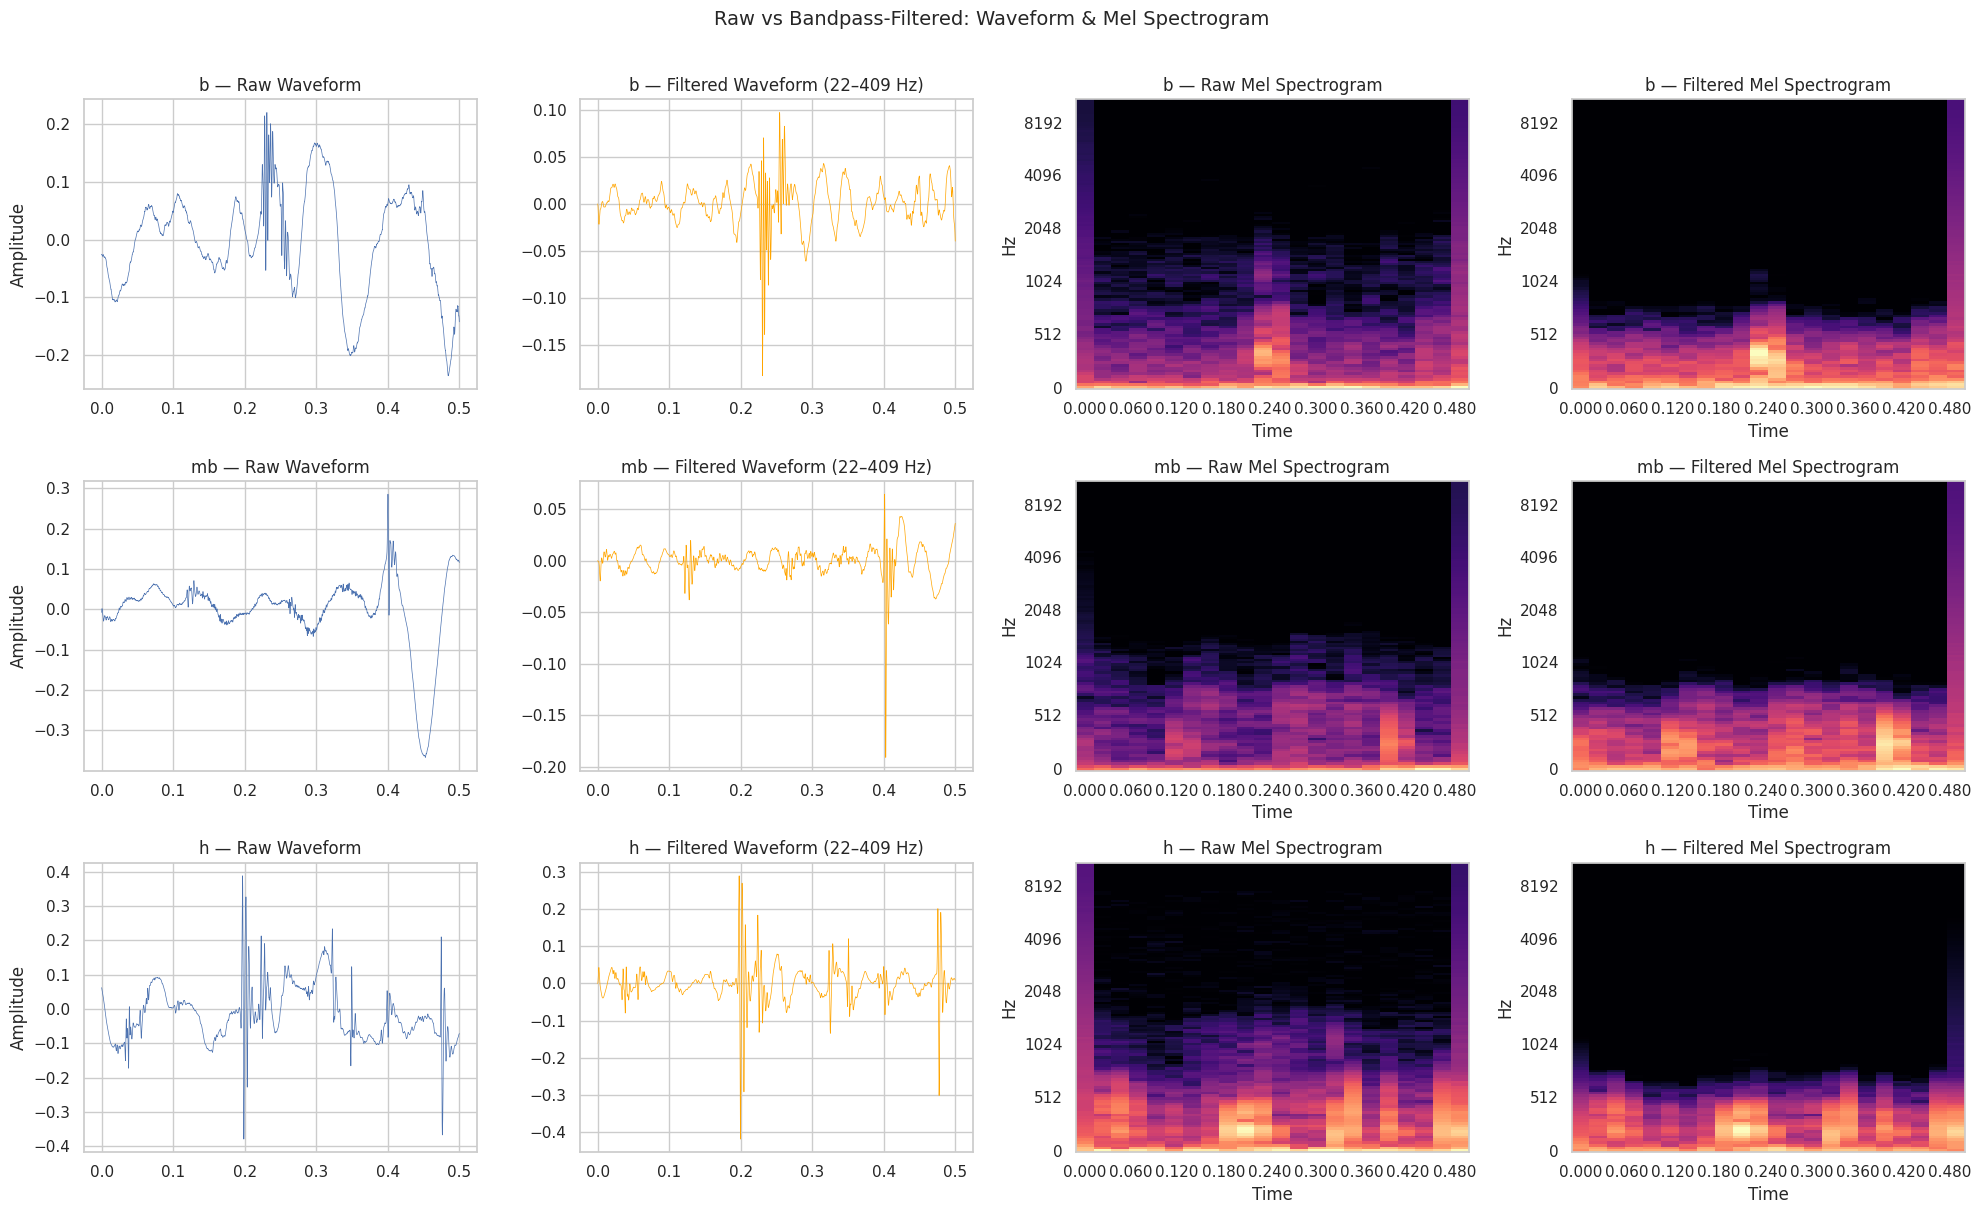

In [3]:
def compute_mel(y):
    S = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return librosa.power_to_db(S, ref=np.max)


fig, axes = plt.subplots(len(TARGET_CLASSES), 4, figsize=(20, 4 * len(TARGET_CLASSES)))
fig.suptitle(
    "Raw vs Bandpass-Filtered: Waveform & Mel Spectrogram", fontsize=14, y=1.01
)

for row, cls in enumerate(TARGET_CLASSES):
    seg = examples[cls]["segment"]
    seg_filt = bandpass_filter(seg, SR, LOW_HZ, HIGH_HZ)
    t = np.linspace(0, CLIP_DUR, len(seg))

    # Raw waveform
    axes[row, 0].plot(t, seg, linewidth=0.5)
    axes[row, 0].set_title(f"{cls} — Raw Waveform")
    axes[row, 0].set_ylabel("Amplitude")

    # Filtered waveform
    axes[row, 1].plot(t, seg_filt, linewidth=0.5, color="orange")
    axes[row, 1].set_title(f"{cls} — Filtered Waveform ({LOW_HZ:.0f}–{HIGH_HZ:.0f} Hz)")

    # Raw mel spectrogram
    librosa.display.specshow(
        compute_mel(seg),
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[row, 2],
    )
    axes[row, 2].set_title(f"{cls} — Raw Mel Spectrogram")

    # Filtered mel spectrogram
    librosa.display.specshow(
        compute_mel(seg_filt),
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[row, 3],
    )
    axes[row, 3].set_title(f"{cls} — Filtered Mel Spectrogram")

plt.tight_layout()
plt.savefig(FIG_DIR / "bandpass_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. PSD Comparison: Raw vs Filtered

Confirm that the bandpass filter preserves the bowel sound frequency band and suppresses out-of-band noise.

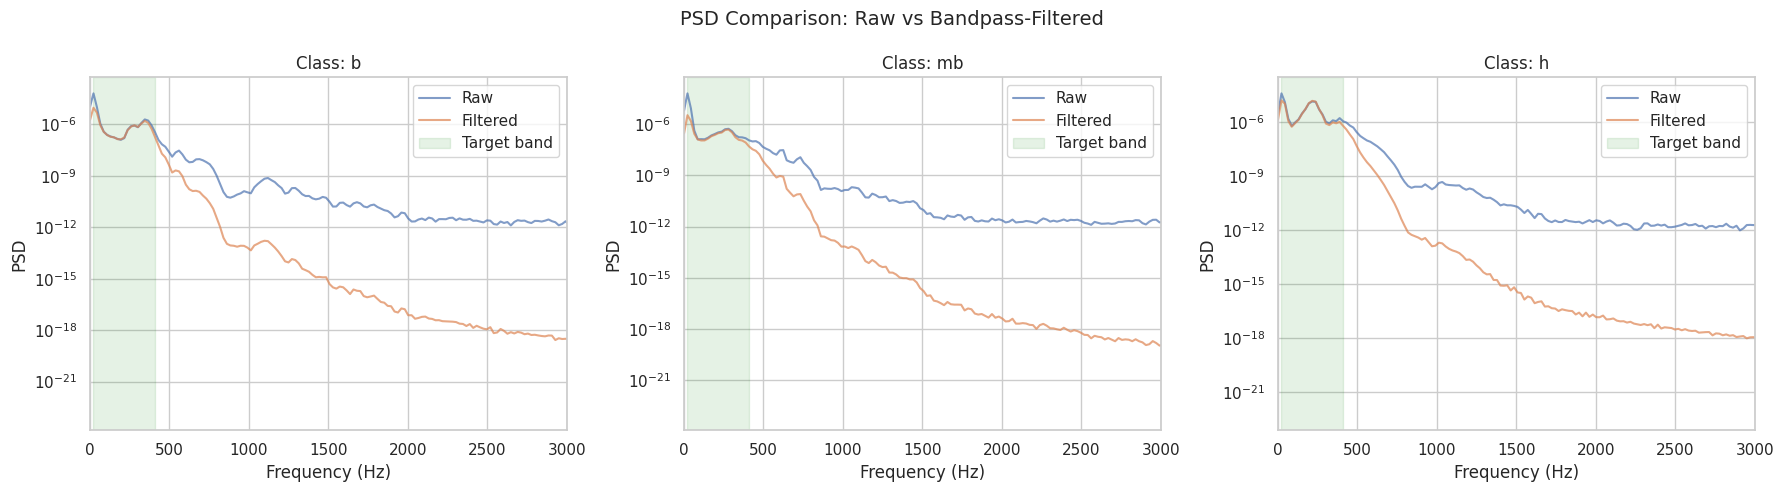

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PSD Comparison: Raw vs Bandpass-Filtered", fontsize=14)

for i, cls in enumerate(TARGET_CLASSES):
    seg = examples[cls]["segment"]
    seg_filt = bandpass_filter(seg, SR, LOW_HZ, HIGH_HZ)

    freqs_raw, psd_raw = welch(seg, fs=SR, nperseg=1024)
    freqs_filt, psd_filt = welch(seg_filt, fs=SR, nperseg=1024)

    axes[i].semilogy(freqs_raw, psd_raw, label="Raw", alpha=0.7)
    axes[i].semilogy(freqs_filt, psd_filt, label="Filtered", alpha=0.7)
    axes[i].axvspan(LOW_HZ, HIGH_HZ, alpha=0.1, color="green", label="Target band")
    axes[i].set_xlabel("Frequency (Hz)")
    axes[i].set_ylabel("PSD")
    axes[i].set_title(f"Class: {cls}")
    axes[i].set_xlim(0, 3000)
    axes[i].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "psd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Augmentation Gallery

One `b` event: original + pitch-shifted + time-stretched + noise-added. Spectrograms side by side.

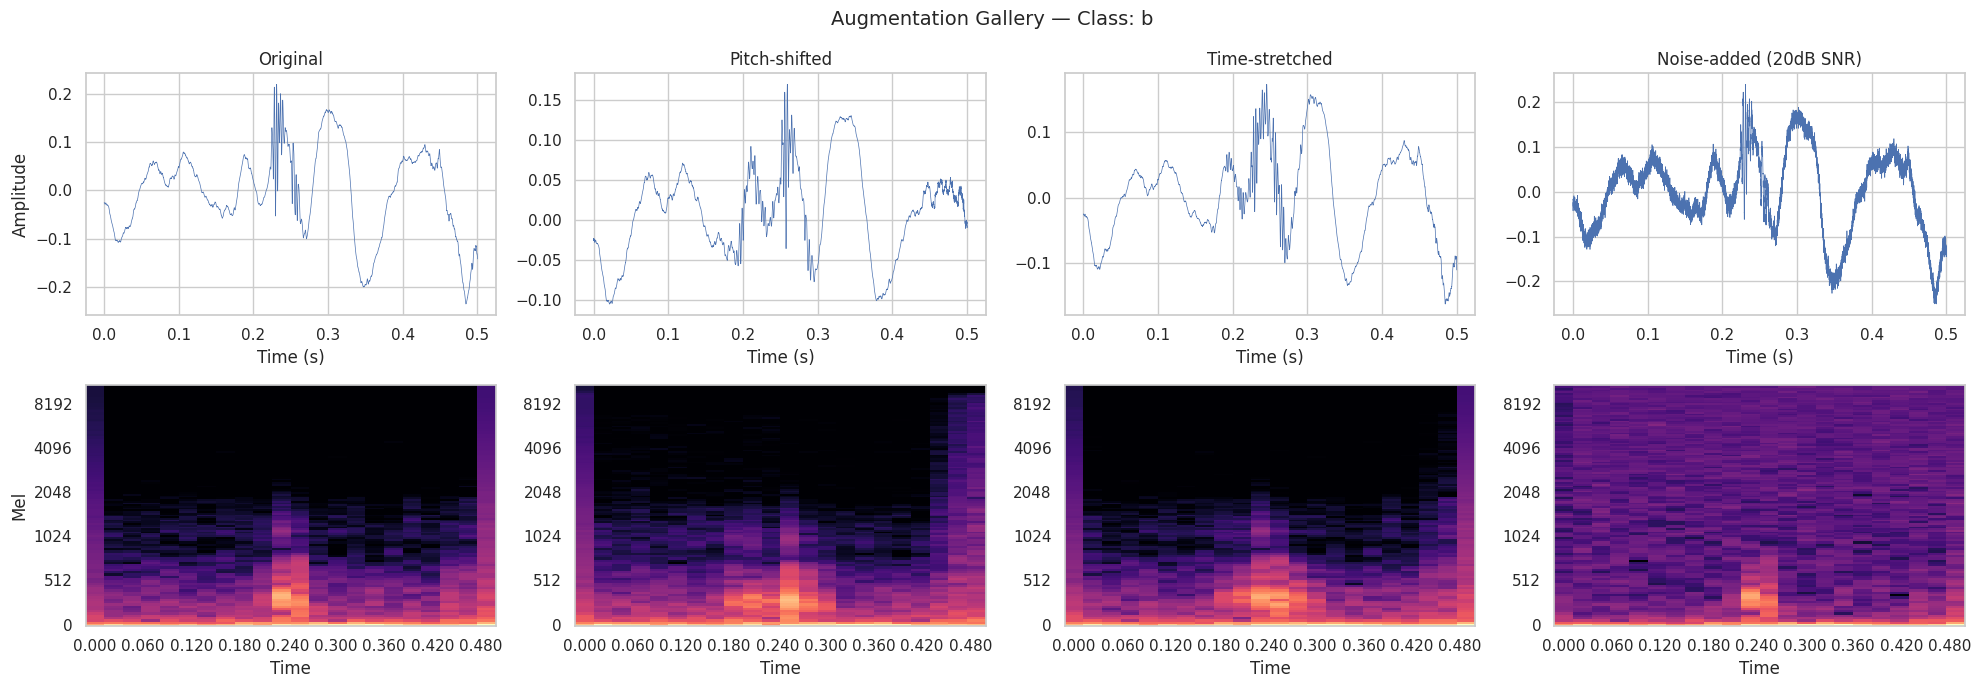

In [5]:
# Generate individual augmented variants for the 'b' example
seg_b = examples["b"]["segment"]
rng = np.random.default_rng(SEED)

pitch_variants = augment_clip(seg_b, SR, methods=("pitch",), rng=rng)
stretch_variants = augment_clip(seg_b, SR, methods=("stretch",), rng=rng)
noise_variants = augment_clip(seg_b, SR, methods=("noise",), rng=rng)

variants = [
    ("Original", seg_b),
    ("Pitch-shifted", pitch_variants[0]),
    ("Time-stretched", stretch_variants[0]),
    ("Noise-added (20dB SNR)", noise_variants[0]),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 7))
fig.suptitle("Augmentation Gallery — Class: b", fontsize=14)

for col, (name, v) in enumerate(variants):
    t = np.linspace(0, CLIP_DUR, len(v))

    # Waveform
    axes[0, col].plot(t, v, linewidth=0.5)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("Amplitude" if col == 0 else "")
    axes[0, col].set_xlabel("Time (s)")

    # Mel spectrogram
    librosa.display.specshow(
        compute_mel(v),
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[1, col],
    )
    axes[1, col].set_ylabel("Mel" if col == 0 else "")

plt.tight_layout()
plt.savefig(FIG_DIR / "augmentation_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Class Balance Before vs After Augmentation

Bar chart comparing class counts in the training set before and after augmentation of minority classes.

Training set class counts:
  Before augmentation: {'b': 779, 'mb': 703, 'h': 76}
  After augmentation:  {'b': 779, 'mb': 703, 'h': 779}


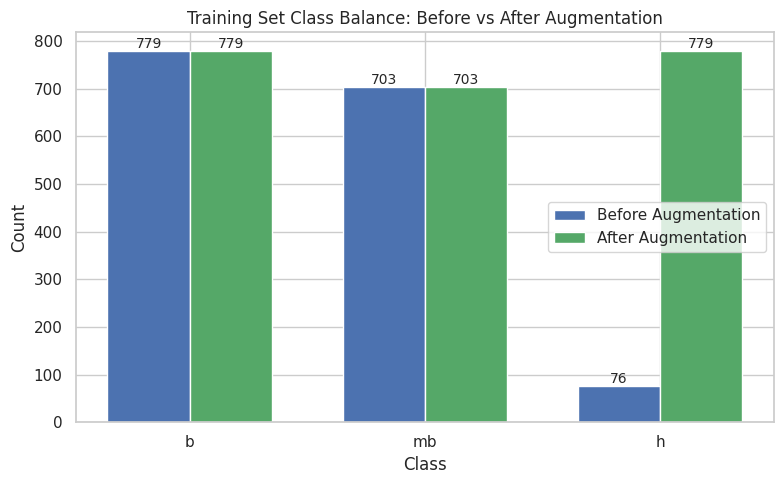

In [6]:
# Get splits without and with augmentation
train_base, _, _ = get_splits(dataset=ds_base)
base_labels = [ds_base.labels[i] for i in train_base.indices]
base_counts = np.bincount(base_labels, minlength=3)

pp_config = {"use_bandpass": True, "use_normalise": True, "use_augmentation": True}
train_aug, _, _ = get_splits(preprocessing_config=pp_config)
aug_counts = np.bincount(train_aug.labels, minlength=3)

print("Training set class counts:")
print(
    f"  Before augmentation: { {c: int(base_counts[i]) for i, c in enumerate(TARGET_CLASSES)} }"
)
print(
    f"  After augmentation:  { {c: int(aug_counts[i]) for i, c in enumerate(TARGET_CLASSES)} }"
)

# Bar chart
x = np.arange(len(TARGET_CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(
    x - width / 2, base_counts, width, label="Before Augmentation", color="#4C72B0"
)
bars2 = ax.bar(
    x + width / 2, aug_counts, width, label="After Augmentation", color="#55A868"
)
ax.bar_label(bars1, fontsize=10)
ax.bar_label(bars2, fontsize=10)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Training Set Class Balance: Before vs After Augmentation")
ax.set_xticks(x)
ax.set_xticklabels(TARGET_CLASSES)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "class_balance_augmentation.png", dpi=150)
plt.show()